# Piecewise Polynomial Sine on ESL-CGRA

| Parameter | Value |
|-----------|-------|
| Function | `sin(x)` |
| Range | [0.0000, 6.2832] |
| Order | 3 (cubic) |
| SHIFT | 13 (segment width = 0.250000 rad) |
| Test point | x = 1.0 |
| Expected | sin(1.0) = 0.8414709848 |


## 1. Run the CGRA simulation

**Important**: `cgra.py` needs this import for FXPMUL to work:
```python
from ctypes import c_int32, c_int64
```


In [4]:
import sys, os, csv, math

# Point to simulator sources (adjust as needed)
sys.path.append("../src/")

from cgra import *

KERNEL  = "sine_approx"
VERSION = ""
Q15     = 32768

load_addrs  = [0, 0, 0, 0]
store_addrs = [10000, 0, 0, 0]

run(KERNEL, version=VERSION,
    pr=["ROUT", "OPS", "R0", "R1", "R2", "R3", "ALL_LAT_INFO", "ALL_PWR_EN_INFO"],
    load_addrs=load_addrs, store_addrs=store_addrs, limit=500)


Instr =  0 ( 0 )
[32768,    0,    0,    0]    [LWD , NOP , NOP , NOP ]    [32768,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [7.13e-05, 3.89e-05, 3.89e-05, 3.89e-05]    [1.43e-12, 7.78e-13, 7.78e-13, 7.78e-13]    
[   0,    0,    0,    0]    [NOP , NOP , NOP , NOP ]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [3.89e-05, 3.89e-05, 3.89e-05, 3.89e-05]    [7.78e-13, 7.78e-13, 7.78e-13, 7.78e-13]    
[   0,    0,    0,    0]    [NOP , NOP , NOP , NOP ]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [3.89e-05, 3.89e-05, 3.89e-05, 3.89e-05]    [7.78e-13, 7.78e-13, 7.78e-13, 7.78e-13]    
[   0,    0,    0,    0]    [NOP , NOP , NOP , NOP ]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [   0,    0,    0,    0]    [3.89e-05, 3.89e-05, 3.89e-05, 3.89e-05]  

## 2. Read result and compare

In [5]:
mem_path = os.path.join(KERNEL, "memory_out" + VERSION + ".csv")
with open(mem_path) as f:
    mem_out = {int(r[0]): int(r[1]) for r in csv.reader(f)}

x_test   = 1.0
result   = mem_out.get(10000)
expected = math.sin(x_test)

print(f'Q15 integer  : {result}')
print(f'Float result : {result/Q15:.10f}')
print(f'Expected     : {expected:.10f}')
print(f'Abs error    : {abs(result/Q15 - expected):.2e}')


Q15 integer  : 27573
Float result : 0.8414611816
Expected     : 0.8414709848
Abs error    : 9.80e-06


## 3. Sweep the full range

In [6]:
import numpy as np
sys.path.insert(0, '.')
import generate_sine_lut as gen

X_MIN, X_MAX = 0.0, 6.283185307179586
SHIFT, ORDER = 13, 3

segments, n_seg, step_q15 = gen.generate_lut(math.sin, X_MIN, X_MAX, SHIFT, ORDER)

xs = np.linspace(X_MIN + 0.001, X_MAX - 0.001, 80)
results, expecteds = [], []

for xt in xs:
    gen.write_memory(KERNEL, xt, X_MIN, segments, ORDER, version=VERSION)
    run(KERNEL, version=VERSION, pr=[], load_addrs=[0,0,0,0],
        store_addrs=[10000,0,0,0], limit=500)
    with open(os.path.join(KERNEL, "memory_out" + VERSION + ".csv")) as f:
        mo = {int(r[0]): int(r[1]) for r in csv.reader(f)}
    val = mo.get(10000)
    results.append(val / Q15 if val is not None else float('nan'))
    expecteds.append(math.sin(xt))

results   = np.array(results)
expecteds = np.array(expecteds)
errors    = np.abs(results - expecteds)

print(f'Points tested  : {len(xs)}')
print(f'Max abs error  : {np.nanmax(errors):.6e}')
print(f'Mean abs error : {np.nanmean(errors):.6e}')


Instr =  0 ( 0 )




-------
Instr =  1 ( 1 )




-------
Instr =  2 ( 2 )




-------
Instr =  3 ( 3 )




-------
Instr =  4 ( 4 )




-------
Instr =  5 ( 5 )




-------
Instr =  6 ( 6 )




-------
Instr =  7 ( 7 )




-------
Instr =  8 ( 8 )




-------
Instr =  9 ( 9 )




-------
Instr =  10 ( 10 )




-------
Instr =  11 ( 11 )




-------
Instr =  12 ( 12 )




-------
Instr =  13 ( 13 )




-------
Instr =  14 ( 14 )




-------
Instr =  15 ( 15 )




-------
Instr =  16 ( 16 )




-------
Instr =  17 ( 17 )




-------
Instr =  18 ( 18 )




-------
Instr =  19 ( 19 )




-------
Instr =  20 ( 20 )




-------
Instr =  21 ( 21 )






END
Instr =  0 ( 0 )




-------
Instr =  1 ( 1 )




-------
Instr =  2 ( 2 )




-------
Instr =  3 ( 3 )




-------
Instr =  4 ( 4 )




-------
Instr =  5 ( 5 )




-------
Instr =  6 ( 6 )




-------
Instr =  7 ( 7 )




-------
Instr =  8 ( 8 )




-------
Instr =  9 ( 9 )




-------
Instr =  10 ( 10 )




-------
Instr =  11 ( 11 )


## 4. Plot results

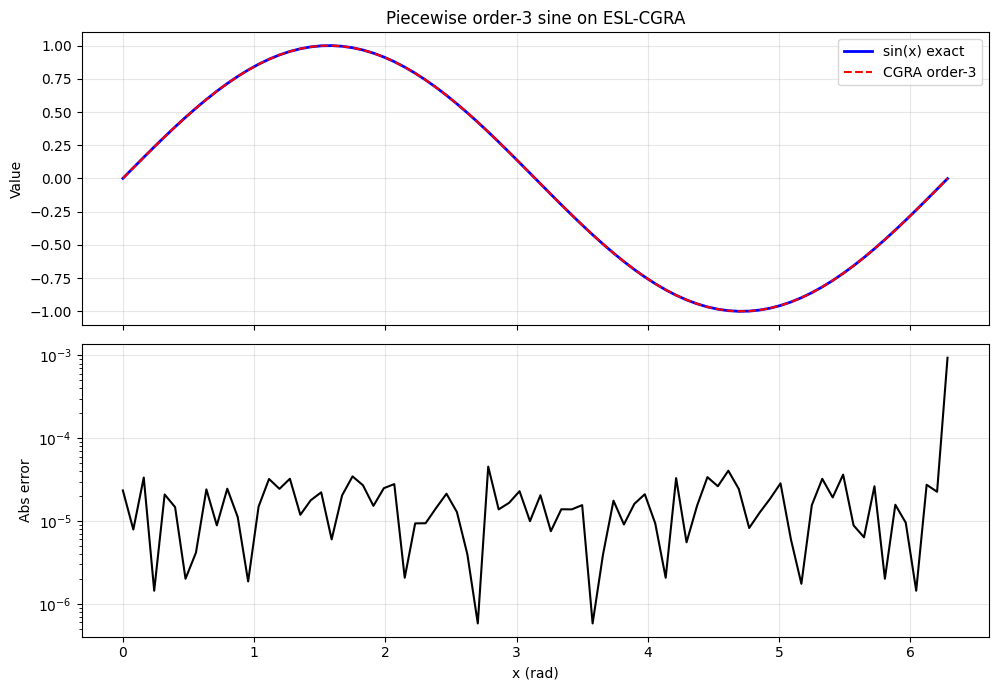

In [7]:
try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    ax1.plot(xs, expecteds, 'b-', lw=2, label='sin(x) exact')
    ax1.plot(xs, results, 'r--', lw=1.5, label='CGRA order-3')
    ax1.legend(); ax1.set_ylabel('Value'); ax1.grid(True, alpha=0.3)
    ax1.set_title('Piecewise order-3 sine on ESL-CGRA')
    ax2.semilogy(xs, errors, 'k-')
    ax2.set_ylabel('Abs error'); ax2.set_xlabel('x (rad)'); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(KERNEL, 'accuracy.png'), dpi=150); plt.show()
except ImportError:
    print('matplotlib not available')


## 5. Regenerate with different parameters

Uncomment and edit to try a different configuration:

In [8]:
# import generate_sine_lut as gen
# gen.generate_all(
#     func=math.sin, func_name='sin',
#     x_min=0.0, x_max=2*math.pi,
#     shift=11,    # finer segments (more accuracy)
#     order=2,     # quadratic
#     x_test=1.5,
#     kernel_name='sine_approx',
# )
